# Using the Trajectory-based Channel Model

In [1]:
import numpy as np
import os, time
import scipy
import matplotlib.pyplot as plt

from neoradium import DeepMimoData, TrjChannel, Carrier, Grid, Modem, AntennaPanel, random
from neoradium.utils import getNmse

In [2]:
# Replace this with the folder on your computer where you store DeepMIMO scenarios
dataFolder = "/data/RayTracing/DeepMIMO/Scenarios/V4/"
DeepMimoData.setScenariosPath(dataFolder)

# Create a DeepMimoData object
deepMimoData = DeepMimoData("asu_campus_3p5")
deepMimoData.print()


DeepMimoData Properties:
  Scenario:                   asu_campus_3p5
  Version:                    4.0.0a3
  UE Grid:                    rx_grid
  Grid Size:                  411 x 321
  Base Station:               BS (at [166. 104.  22.])
  Total Grid Points:          131,931
  UE Spacing:                 [1. 1.]
  UE bounds (xyMin, xyMax)    [-225.55 -160.17], [184.45 159.83]
  UE Height:                  1.50
  Carrier Frequency:          3.5 GHz
  Num. paths (Min, Avg, Max): 0, 6.21, 10
  Num. total blockage:        46774
  LOS percentage:             19.71%




Trajectory Properties:
  start (x,y,z):         (-164.55, 69.83, 1.50)
  No. of points:         7968
  curIdx:                0 (0.00%)
  curSpeed:              [21.28 21.28  0.  ]
  Total distance:        240.42 meters
  Total time:            7.967 seconds
  Average Speed:         30.177 m/s
  Carrier Frequency:     3.5 GHz
  Paths (Min, Avg, Max): 5, 8.79, 10
  Totally blocked:       0
  LOS percentage:        59.43%



(<Figure size 742.518x471.734 with 1 Axes>,
 <Axes: title={'center': 'Map of LOS/NLOS paths'}, xlabel='X', ylabel='Y'>)

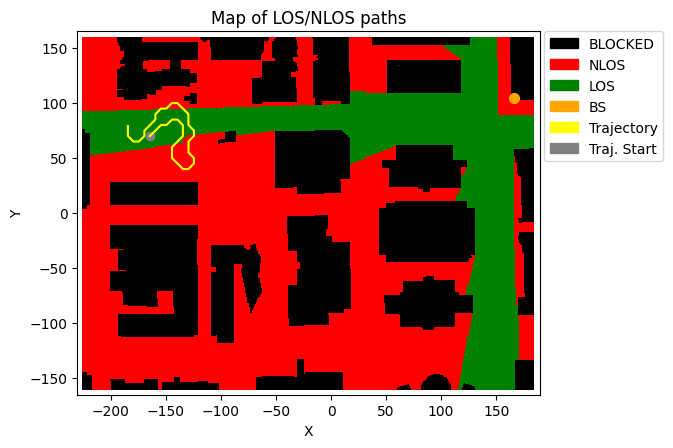

In [3]:
random.setSeed(123)                                 # Make results reproducible

# Create the carrier:
carrier = Carrier(startRb=0, numRbs=25, spacing=15) # Carrier with 25 Resource Blocks, 15KHz subcarrier spacing
bwp = carrier.curBwp                                # The only bandwidth part in the carrier

# Create a random trajectory at waking speed.
trajectory = deepMimoData.getRandomTrajectory(xyBounds=np.array([[-210, 40], [-120, 100]]),   # Traj. bounds
                                              segLen=5,               # Num grid points on shortest segment
                                              bwp=bwp,                # The bandwidth part
                                              trajLen=200,            # Number of grid points on trajectory
                                              speedMps=30)           # Speed in mps (Walking)

trajectory.print()                                  # Print the trajectory information
deepMimoData.drawMap("LOS-NLOS", trajectory)        # Draw the Map with the trajectory

In [4]:
# Create a random grid
txGrid = bwp.createGrid(numPlanes=16)                   # Create an empty resource grid

stats = txGrid.getStats()                              # Get statistics about the grid
modem = Modem("16QAM")                                 # Using 16QAM modulation
numRandomBits = stats['UNASSIGNED']*modem.qm           # Total number of bits available in the resource grid

bits = random.bits(numRandomBits)                      # Create random bits
symbols = modem.modulate(bits)                         # Modulate the bits to get symbols

indexes = txGrid.getReIndexes("UNASSIGNED")            # Indexes of the "UNASSIGNED" resources
txGrid[indexes] = symbols                              # Put symbols in the resource grid

txWaveform = txGrid.ofdmModulate()                     # OFDM-Modulate the resource grid to get a waveform

print("Shape of Resource Grid:",txGrid.shape)
print("Shape of Waveform:     ",txWaveform.shape)

Shape of Resource Grid: (16, 14, 300)
Shape of Waveform:      (16, 30720)


In [5]:
# Create a MIMO channel model based on our trajectory.
channel = TrjChannel(bwp, trajectory,
                     txAntenna = AntennaPanel([2,4], polarization="x"),       # 8 TX antenna
                     txOrientation = [180,0,0],                               # Facing left
                     rxAntenna = AntennaPanel([1,2], polarization="x"),       # 2 RX antenna
                     interpolateSlots = True,
                     seed=123)
print(channel)


TrjChannel Properties:
  carrierFreq:          3.5 GHz
  normalizeGains:       True
  normalizeOutput:      True
  normalizeDelays:      True
  interpolateSlots:     True
  xPolPower:            10.00 (dB)
  filterLen:            16 samples
  delayQuantSize:       64
  stopBandAtten:        80 dB
  dopplerShift:         353.7814505317208 Hz
  coherenceTime:        0.0011960553246215984 sec
  TX Antenna:
    Total Elements:     16
    spacing:            0.5𝜆, 0.5𝜆
    shape:              2 rows x 4 columns
    polarization:       x
    Orientation (𝛼,𝛃,𝛄): 180° 0° 0°
  RX Antenna:
    Total Elements:     4
    spacing:            0.5𝜆, 0.5𝜆
    shape:              1 rows x 2 columns
    polarization:       x
  Trajectory:
    start (x,y,z):         (-164.55, 69.83, 1.50)
    No. of points:         7968
    curIdx:                0 (0.00%)
    curSpeed:              [21.28 21.28  0.  ]
    Total distance:        240.42 meters
    Total time:            7.967 seconds
    Average Speed: 

In [6]:
# Apply the channel in Frequency Domain:
t0 =time.time()
channelMatrix = channel.getChannelMatrix()
rxGridF = txGrid.applyChannel(channelMatrix)
t1 =time.time()
print("Time to apply channel in Freq. Domain:", t1-t0)

Time to apply channel in Freq. Domain: 0.012088775634765625


In [7]:
# Applying the channel in time domain and demodulate to get a received resource grid (rxGrid)
t0 =time.time()
maxDelay = channel.getMaxDelay()                         # Calculate the channel's max delay
paddedTxWaveform = txWaveform.pad(maxDelay)              # Pad the waveform with zeros
rxWaveform = channel.applyToSignal(paddedTxWaveform)     # Apply the channel to the waveform
offset = channel.getTimingOffset()                       # Get the timing offset for synchronization
syncedWaveform = rxWaveform.sync(offset)                 # Synchronization
rxGridT = Grid.ofdmDemodulate(bwp, syncedWaveform)       # OFDM-demodulation
t1 =time.time()
print("Time to apply channel in Time Domain:", t1-t0)
print("NMSE between the rxGrid in Time and Freq. domains: ",getNmse(rxGridT.grid,rxGridF.grid)) 


Time to apply channel in Time Domain: 0.16606688499450684
NMSE between the rxGrid in Time and Freq. domains:  1.9054214875297066e-18


Text(0.5, 1.0, 'The channel values continuum for 140 symbols (10 slots) with and without interpolation')

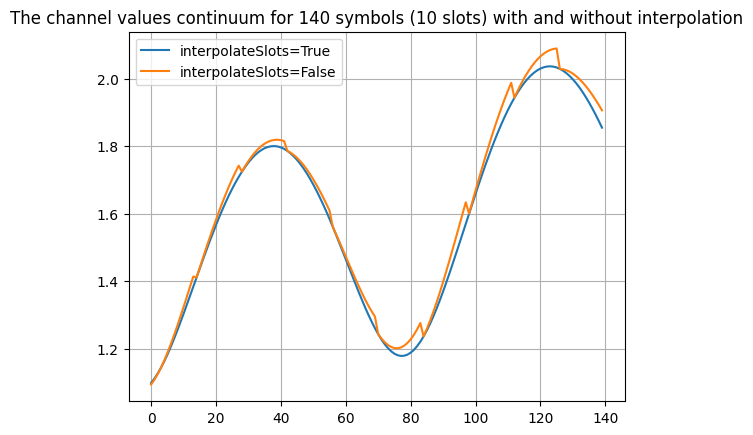

In [8]:
# The following example shows the difference between interpolating the multipath information
# for different symbols in a slot vs using the same multipath information for all symbols in
# a slot.
from matplotlib import pyplot as plt

chanMats = []                       # list of consecutive channel matrixes
channel.interpolateSlots = True     # First: Using interpolation
channel.restart()
t0 = time.monotonic()
for i in range(10):                 # 10 channel matrices
    chanMats += [ channel.getChannelMatrix() ]
    channel.goNext()
chanMats = np.stack(chanMats)       # Shape: 10 x 14 x 300 x 4 x 16

# Sequence of channel values for first subcarrier, between first transmitter and
# first receiver antenna (A sequence 140 complex values)
chanValuesInt = chanMats[:,:,0,0,0].flatten()    

chanMats = []                       # Reset the list
channel.interpolateSlots = False    # Now not using interpolation
channel.restart()
t0 = time.monotonic()
for i in range(10):                 # 10 channel matrices
    chanMats += [ channel.getChannelMatrix() ]
    channel.goNext()
chanMats = np.stack(chanMats)       # Shape: 10 x 14 x 300 x 4 x 16
chanValuesNoInt = chanMats[:,:,0,0,0].flatten()    

plt.plot(np.abs(chanValuesInt), label="interpolateSlots=True")
plt.plot(np.abs(chanValuesNoInt), label="interpolateSlots=False")
plt.grid()
plt.legend()
plt.title("The channel values continuum for 140 symbols (10 slots) with and without interpolation")
